# Problem 2: Splines

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

In [13]:
def f(x):
    return np.sin(20*x)

def spline_error(n, func, interval, bc_type, test_interval):
    a, b = interval

    # create nodes
    x_nodes = np.linspace(a, b, n+1)
    y_nodes = func(x_nodes)

    # build spline
    spline = CubicSpline(x_nodes, y_nodes, bc_type=bc_type)

    # test points
    x_test = np.random.uniform(test_interval[0], test_interval[1], 100000)

    # compute error
    error = np.abs(func(x_test) - spline(x_test))

    return np.max(error)

n_values = [5, 10, 20, 40, 80, 160]

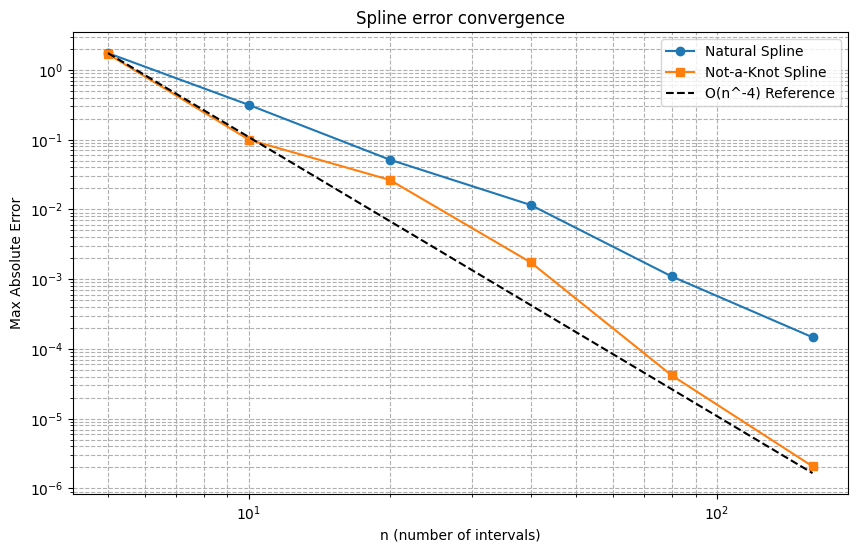

In [14]:
# Test points from [1.01, 1.99]
natural_errors = []
notaknot_errors = []

for n in n_values:
    e1 = spline_error(
        n,
        f,
        interval=(1, 2),
        bc_type='natural',
        test_interval=(1.01, 1.99)
    )

    e2 = spline_error(
        n,
        f,
        interval=(1, 2),
        bc_type='not-a-knot',
        test_interval=(1.01, 1.99)
    )

    natural_errors.append(e1)
    notaknot_errors.append(e2)

# Predicted slope is O(h^4) 
predicted_slope = -4

# Plot convergence
plt.figure(figsize=(10, 6))
plt.loglog(n_values, natural_errors, 'o-', label='Natural Spline')
plt.loglog(n_values, notaknot_errors, 's-', label='Not-a-Knot Spline')
# Plot reference line for O(h^4)
h_values = np.array(n_values)
reference_line = (h_values / h_values[0])**predicted_slope * natural_errors[0]
plt.loglog(n_values, reference_line, 'k--', label='O(n^-4) Reference')

plt.xlabel('n (number of intervals)')
plt.ylabel('Max Absolute Error')
plt.title('Spline error convergence')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

## 2b

The plot shows that the errors decreases approximately like $n^{-4}$, which corresponds to the expected $O(h^4)$ convergence rate for cubic spline interpolation. The not-a-know spline performs slightly better than the natural spline due to the boundary conditions imosed on the spline.

## 2c

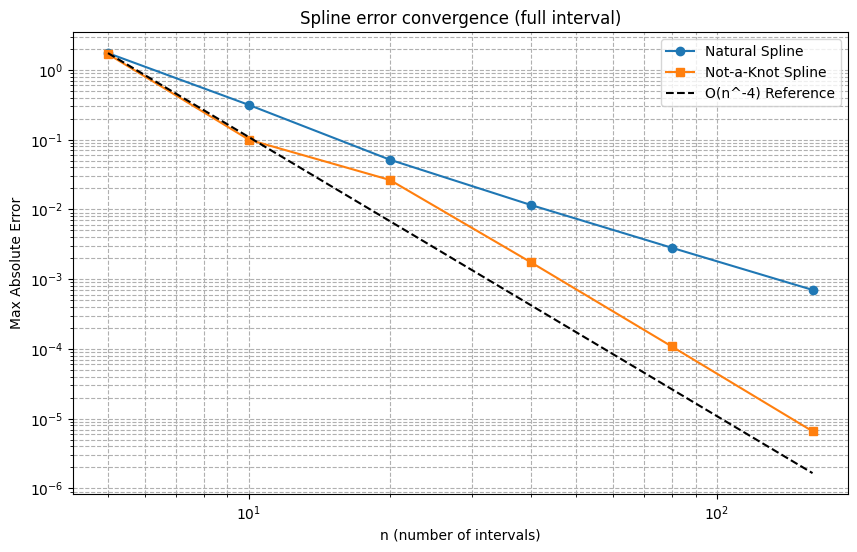

In [15]:
natural_errors_full = []
notaknot_errors_full = []

for n in n_values:

    e1 = spline_error(
        n,
        f,
        interval=(1, 2),
        bc_type='natural',
        test_interval=(1, 2)
    )

    e2 = spline_error(
        n,
        f,
        interval=(1, 2),
        bc_type='not-a-knot',
        test_interval=(1, 2)
    )

    natural_errors_full.append(e1)
    notaknot_errors_full.append(e2)

plt.figure(figsize=(10, 6))
plt.loglog(n_values, natural_errors_full, 'o-', label='Natural Spline')
plt.loglog(n_values, notaknot_errors_full, 's-', label='Not-a-Knot Spline')
# Plot reference line for O(h^4)
h_values = np.array(n_values)
reference_line = (h_values / h_values[0])**predicted_slope * natural_errors_full[0]
plt.loglog(n_values, reference_line, 'k--', label='O(n^-4) Reference')

plt.xlabel('n (number of intervals)')
plt.ylabel('Max Absolute Error')
plt.title('Spline error convergence (full interval)')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

## 2c
When sampling the points on the full interval, the errors are larger becuase the spline boundary conditions introduce additional error near the endpoints.

## 2d

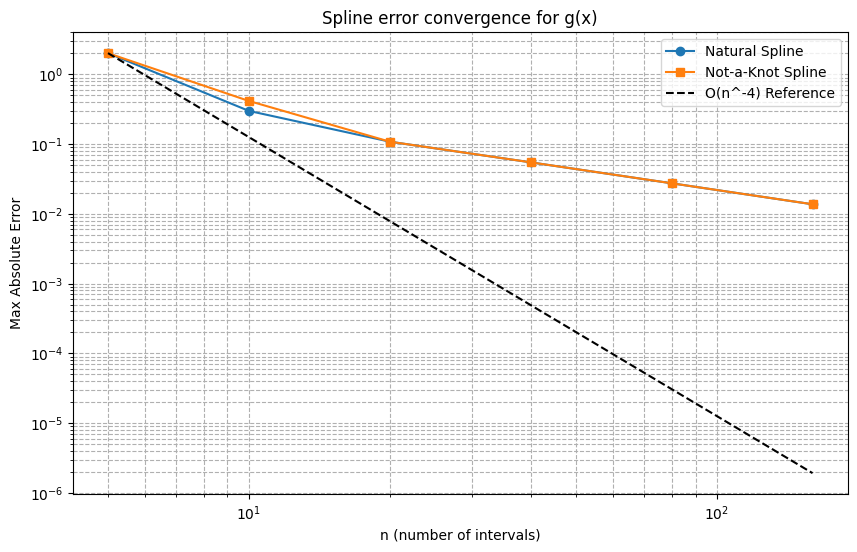

In [16]:
def g(x):
    return np.where(x < 1.3, f(x), f(2.6 - x))

natural_errors_g = []
notaknot_errors_g = []

for n in n_values:

    e1 = spline_error(
        n,
        g,
        interval=(1, 2),
        bc_type='natural',
        test_interval=(1.01, 1.99)
    )

    e2 = spline_error(
        n,
        g,
        interval=(1, 2),
        bc_type='not-a-knot',
        test_interval=(1.01, 1.99)
    )

    natural_errors_g.append(e1)
    notaknot_errors_g.append(e2)

plt.figure(figsize=(10, 6))
plt.loglog(n_values, natural_errors_g, 'o-', label='Natural Spline')
plt.loglog(n_values, notaknot_errors_g, 's-', label='Not-a-Knot Spline')
# Plot reference line for O(h^4)
h_values = np.array(n_values)
reference_line = (h_values / h_values[0])**predicted_slope * natural_errors_g[0]
plt.loglog(n_values, reference_line, 'k--', label='O(n^-4) Reference')
plt.xlabel('n (number of intervals)')
plt.ylabel('Max Absolute Error')
plt.title('Spline error convergence for g(x)')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

The convergence rate is much slower becuase the function $g(x)$ is not smooth at $x=1.3$. The cubic spline accuracy depends on having smooth derivatives, and the derivative discontinuity reduces the convergence order.